Linear+Sigmoid

0 0.7500322461128235
1 0.738373339176178
2 0.7279934287071228
3 0.7187575697898865
4 0.7105436325073242
5 0.7032410502433777
6 0.6967502236366272
7 0.6909818053245544
8 0.6858559846878052
9 0.6813011169433594
10 0.6772534251213074
11 0.6736561059951782
12 0.6704586744308472
13 0.6676161885261536
14 0.6650890111923218
15 0.6628414988517761
16 0.6608421802520752
17 0.659063458442688
18 0.6574805378913879
19 0.6560714244842529
20 0.6548169255256653
21 0.6536996960639954
22 0.6527043581008911
23 0.6518175005912781
24 0.6510270237922668
25 0.6503224968910217
26 0.6496942043304443
27 0.6491338014602661
28 0.6486338973045349
29 0.6481877565383911
30 0.6477896571159363
31 0.6474342346191406
32 0.6471167802810669
33 0.6468333601951599
34 0.646580159664154
35 0.6463538408279419
36 0.6461516618728638
37 0.6459708213806152
38 0.6458092927932739
39 0.6456646919250488
40 0.6455353498458862
41 0.6454196572303772
42 0.6453161239624023
43 0.6452233791351318
44 0.6451404094696045
45 0.6450660228729248
4

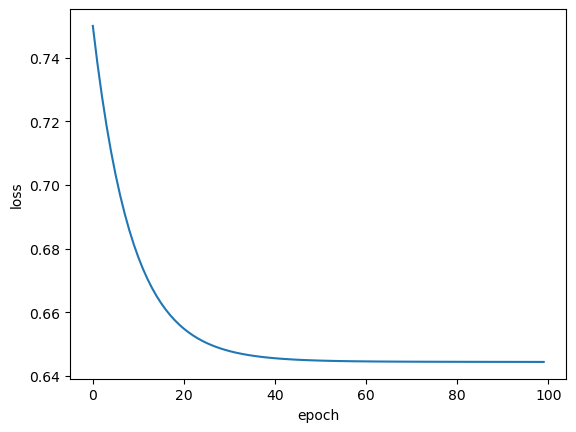

In [ ]:
import numpy as np
import torch
import matplotlib.pyplot as plt
 
# prepare dataset
xy = np.loadtxt('data\diabetes.csv', delimiter=',', dtype=np.float32)
x_data = torch.from_numpy(xy[:, :-1]) # 第一个‘：’是指读取所有行，第二个‘：’是指从第一列开始，最后一列不要
y_data = torch.from_numpy(xy[:, [-1]]) # [-1] 最后得到的是个矩阵
 
# design model using class
 
 
class Model(torch.nn.Module):
    def __init__(self):
        super(Model, self).__init__()
        self.linear1 = torch.nn.Linear(8, 6) # 输入数据x的特征是8维，x有8个特征
        self.linear2 = torch.nn.Linear(6, 4)
        self.linear3 = torch.nn.Linear(4, 1)
        self.activate = torch.nn.Sigmoid() # 将其看作是网络的一层，而不是简单的函数使用
 
    def forward(self, x):
        x = self.activate(self.linear1(x))
        x = self.activate(self.linear2(x))
        x = self.activate(self.linear3(x)) # y hat
        return x
 
 
model = Model()
 
# construct loss and optimizer
# criterion = torch.nn.BCELoss(size_average = True)
criterion = torch.nn.BCELoss(reduction='mean')  
optimizer = torch.optim.SGD(model.parameters(), lr=0.1)
 
epoch_list = []
loss_list = []
# training cycle forward, backward, update
for epoch in range(100):
    y_pred = model(x_data)
    loss = criterion(y_pred, y_data)
    print(epoch, loss.item())
    epoch_list.append(epoch)
    loss_list.append(loss.item())
 
    optimizer.zero_grad()
    loss.backward()
 
    optimizer.step()
 
 
plt.plot(epoch_list, loss_list)
plt.ylabel('loss')
plt.xlabel('epoch')
plt.show()

Linear+ReLU

0 0.6874960064888
1 0.6846092939376831
2 0.681918203830719
3 0.6794073581695557
4 0.677059531211853
5 0.674867570400238
6 0.6728229522705078
7 0.6709163188934326
8 0.6691404581069946
9 0.6674880385398865
10 0.665954053401947
11 0.6645272374153137
12 0.6632003784179688
13 0.6619749069213867
14 0.6608349084854126
15 0.6597739458084106
16 0.6587862372398376
17 0.6578648090362549
18 0.6570125222206116
19 0.6562219858169556
20 0.6554868817329407
21 0.6548037528991699
22 0.6541663408279419
23 0.6535738110542297
24 0.6530253291130066
25 0.6525136828422546
26 0.6520352959632874
27 0.6515892744064331
28 0.6511706709861755
29 0.6507789492607117
30 0.6504155993461609
31 0.6500778198242188
32 0.6497595310211182
33 0.6494640111923218
34 0.6491878628730774
35 0.648931622505188
36 0.6486914753913879
37 0.6484645009040833
38 0.6482496857643127
39 0.6480455994606018
40 0.6478539109230042
41 0.6476740837097168
42 0.6475037932395935
43 0.6473427414894104
44 0.6471905708312988
45 0.6470461487770081
46 0.6

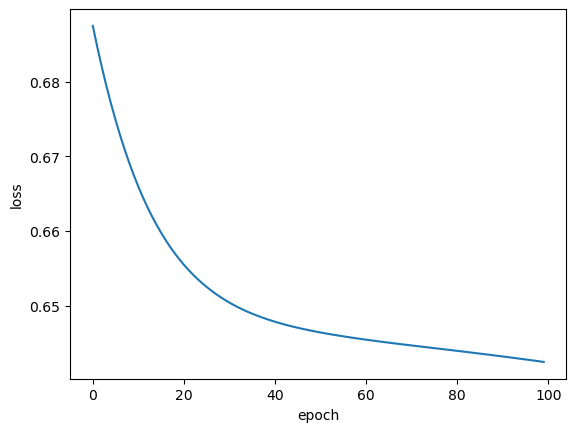

In [9]:
import numpy as np
import torch
import matplotlib.pyplot as plt
 
# prepare dataset
xy = np.loadtxt('data\diabetes.csv', delimiter=',', dtype=np.float32)
x_data = torch.from_numpy(xy[:, :-1]) # 第一个‘：’是指读取所有行，第二个‘：’是指从第一列开始，最后一列不要
y_data = torch.from_numpy(xy[:, [-1]]) # [-1] 最后得到的是个矩阵
 
# design model using class
 
 
class Model(torch.nn.Module):
    def __init__(self):
        super(Model, self).__init__()
        self.linear1 = torch.nn.Linear(8, 6) # 输入数据x的特征是8维，x有8个特征
        self.linear2 = torch.nn.Linear(6, 4)
        self.linear3 = torch.nn.Linear(4, 1)
        self.activate = torch.nn.ReLU() # 将其看作是网络的一层，而不是简单的函数使用
 
    def forward(self, x):
        x = self.activate(self.linear1(x))
        x = self.activate(self.linear2(x))
        x = self.linear3(x) # y hat
        return x
 
 
model = Model()
 
# construct loss and optimizer
# criterion = torch.nn.BCELoss(size_average = True)
criterion = torch.nn.BCEWithLogitsLoss(reduction='mean')  
optimizer = torch.optim.SGD(model.parameters(), lr=0.1)
 
epoch_list = []
loss_list = []
# training cycle forward, backward, update
for epoch in range(100):
    y_pred = model(x_data)
    loss = criterion(y_pred, y_data)
    print(epoch, loss.item())
    epoch_list.append(epoch)
    loss_list.append(loss.item())
 
    optimizer.zero_grad()
    loss.backward()
 
    optimizer.step()
 
 
plt.plot(epoch_list, loss_list)
plt.ylabel('loss')
plt.xlabel('epoch')
plt.show()

In [ ]:
import numpy as np
import torch
import matplotlib.pyplot as plt
 
# prepare dataset
xy = np.loadtxt('diabetes.csv', delimiter=',', dtype=np.float32)
x_data = torch.from_numpy(xy[:, :-1]) # 第一个‘：’是指读取所有行，第二个‘：’是指从第一列开始，最后一列不要
print("input data.shape", x_data.shape)
y_data = torch.from_numpy(xy[:, [-1]]) # [-1] 最后得到的是个矩阵
 
# print(x_data.shape)
# design model using class
 
 
class Model(torch.nn.Module):
    def __init__(self):
        super(Model, self).__init__()
        self.linear1 = torch.nn.Linear(8, 6)
        self.linear2 = torch.nn.Linear(6, 4)
        self.linear3 = torch.nn.Linear(4, 2)
        self.linear4 = torch.nn.Linear(2, 1)
        self.sigmoid = torch.nn.Sigmoid()
 
    def forward(self, x):
        x = self.sigmoid(self.linear1(x))
        x = self.sigmoid(self.linear2(x))
        x = self.sigmoid(self.linear3(x)) # y hat
        x = self.sigmoid(self.linear4(x))  # y hat
        return x
 
 
model = Model()
 
# construct loss and optimizer
# criterion = torch.nn.BCELoss(size_average = True)
criterion = torch.nn.BCELoss(reduction='mean')
optimizer = torch.optim.SGD(model.parameters(), lr=0.1)
 
 
# training cycle forward, backward, update
for epoch in range(1000000):
    y_pred = model(x_data)
    loss = criterion(y_pred, y_data)
    # print(epoch, loss.item())
 
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
 
    if epoch%100000 == 99999:
        y_pred_label = torch.where(y_pred>=0.5,torch.tensor([1.0]),torch.tensor([0.0]))
 
        acc = torch.eq(y_pred_label, y_data).sum().item()/y_data.size(0)
        print("loss = ",loss.item(), "acc = ",acc)
 
 